In [289]:
import json
from pathlib import Path
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)

In [379]:
# BASE_DIR = Path("../assets/experiments/2026-03-10_21-07-34__1-4_secs")
BASE_DIR = Path("../assets/experiments/2026-03-10_22-27-04__10-14_secs")
# BASE_DIR = Path("../assets/experiments/2026-03-11_10-48-53__5-15_secs")

BALANCER_DIR = BASE_DIR / "baseline"
REPL_NO_ADAPT_DIR = BASE_DIR / "non_adaptive"
REPL_ADAPT_DIR = BASE_DIR / "adaptive"

print(BASE_DIR)

..\assets\experiments\2026-03-10_22-27-04__10-14_secs


In [380]:
def load_experiment(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [381]:
def extract_method(data):
    factors = data["factors"]

    balancer = factors.get("balancer")
    replication = factors.get("replication")
    adaptive = factors.get("adaptive")

    if replication:
        return f"{balancer} | {replication} | {'adaptive' if adaptive else 'no_adaptive'}"

    return f"{balancer} | no_replication"

In [382]:
def flatten_requests(data, method, group):
    rows = []

    for req in data["requests"]:

        upstream = req.get("upstream", {})
        signals = req.get("signals", {})

        sockets = upstream.get("sockets", [])
        winner = upstream.get("winner_socket")

        if sockets:
            replicas = len(sockets)
        else:
            replicas = 1

        rows.append({
            "method": method,
            "group": group,

            "req_id": req["req_id"],
            "endpoint": req["endpoint"],

            "latency_ms": req["latency_ms"],
            "status": req["status"],
            "ok": req["ok"],

            "winner_socket": winner,
            "backend_port": signals.get("port"),

            "replicas": replicas,

            "cpu_util": signals.get("cpu_util"),
            "mem_util": signals.get("mem_util"),
            "cpu_burn": signals.get("cpu_burn"),
            "mem_burn": signals.get("mem_burn"),
        })

    return pd.DataFrame(rows)

In [383]:
def load_folder(folder, group):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        method = extract_method(data)

        df = flatten_requests(data, method, group)

        dfs.append(df)

    return dfs


dfs = []

dfs += load_folder(BALANCER_DIR, "balancer_only")
dfs += load_folder(REPL_NO_ADAPT_DIR, "replication_no_adaptive")
dfs += load_folder(REPL_ADAPT_DIR, "replication_adaptive")

df = pd.concat(dfs, ignore_index=True)

df.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,backend_port,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,airm | no_replication,balancer_only,req-0,mem?seconds=11&mb=100,11250.4715,200,True,None,8001.0,1,24.0,19.3,None,True
1,airm | no_replication,balancer_only,req-1,mem?seconds=12&mb=100,12256.3525,200,True,None,8006.0,1,24.6,19.6,None,True
2,airm | no_replication,balancer_only,req-2,mem?seconds=10&mb=100,10227.3450,200,True,None,8006.0,1,20.4,17.2,None,True
3,airm | no_replication,balancer_only,req-3,cpu?seconds=11,11096.4134,200,True,None,8006.0,1,25.7,19.4,True,None
4,airm | no_replication,balancer_only,req-4,cpu?seconds=10,10117.9071,200,True,None,8002.0,1,19.7,17.2,True,None


In [384]:
def p50(x):
    return np.percentile(x, 50)


def p95(x):
    return np.percentile(x, 95)


def p99(x):
    return np.percentile(x, 99)

# Latency

In [385]:
latency_stats = (
    df
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

latency_stats

,mean,p50,p95,p99
method,,,,
airm | speculative | adaptive,12247.553532,11547.00730,15255.876995,18222.882245
electre | speculative | adaptive,12472.575784,12100.30855,15649.094160,18239.108515
topsis | hedged | adaptive,12482.592002,12095.20975,15642.230155,18217.133251
topsis | speculative | adaptive,12605.223522,12115.75020,15635.861795,18223.010522
topsis | no_replication,12770.813239,12084.72090,17857.778030,21412.837643
electre | hedged | adaptive,12829.508422,12287.32660,17016.942290,18236.427120
airm | hedged | adaptive,12977.889647,12697.61075,17067.851330,18236.271407
electre | no_replication,13741.813786,12277.92235,21926.810485,30201.334390
airm | speculative | no_adaptive,13837.867282,13905.22170,18211.461680,18231.402513


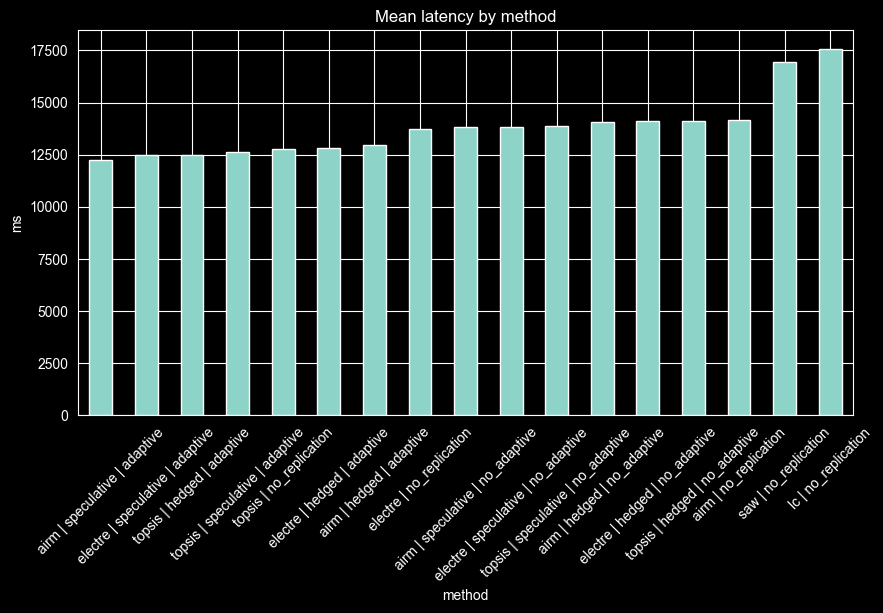

In [386]:
latency_stats["mean"].plot(kind="bar")

plt.title("Mean latency by method")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

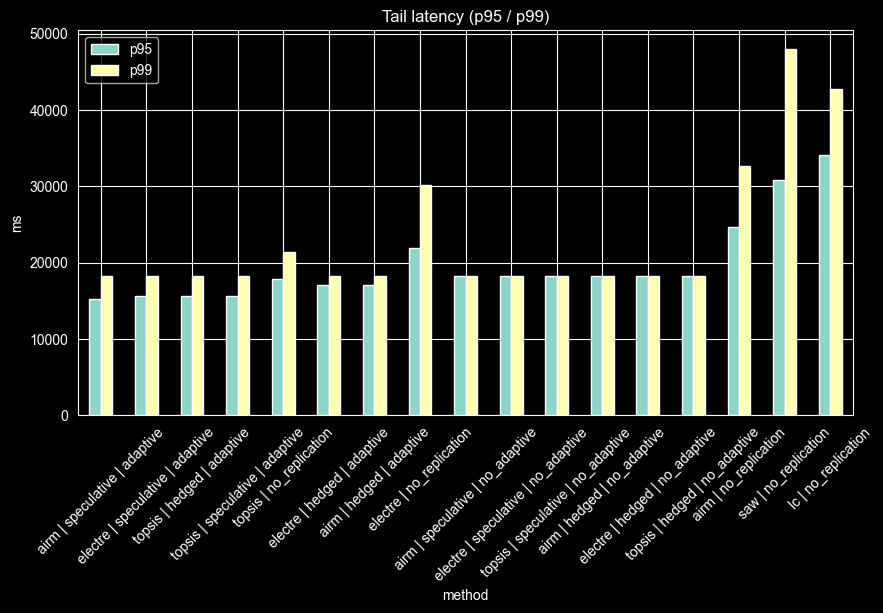

In [387]:
latency_stats[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency (p95 / p99)")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

# WA

In [388]:
wa_stats = (
    df
    .groupby("method")["replicas"]
    .agg(
        mean="mean",
        p95=p95,
        max="max"
    )
    .sort_values("mean")
)

wa_stats

,mean,p95,max
method,,,
airm | no_replication,1.000,1.0,1
electre | no_replication,1.000,1.0,1
lc | no_replication,1.000,1.0,1
saw | no_replication,1.000,1.0,1
topsis | no_replication,1.000,1.0,1
topsis | speculative | adaptive,1.395,3.0,3
topsis | hedged | adaptive,1.432,3.0,3
airm | speculative | adaptive,1.509,3.0,3
electre | hedged | adaptive,1.534,3.0,3


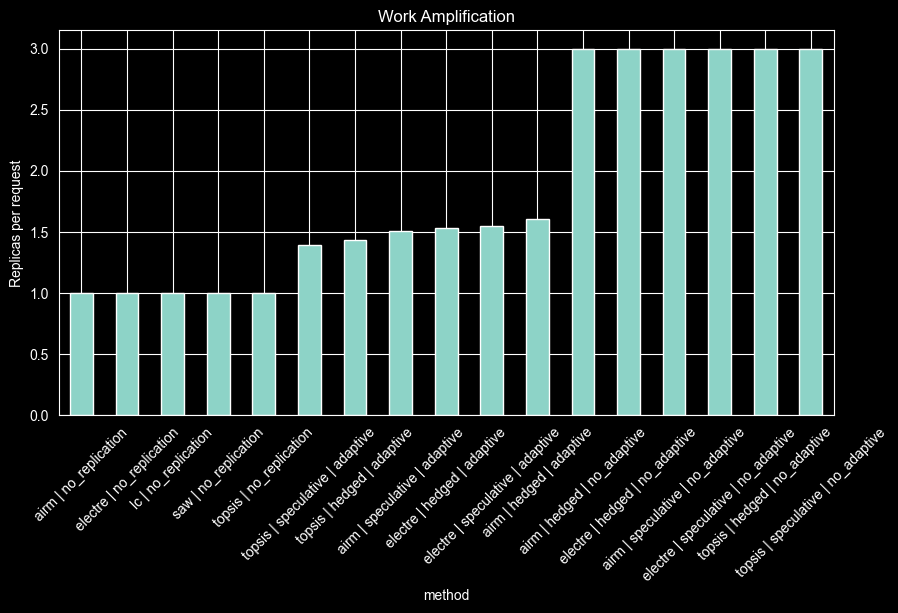

In [389]:
wa_stats["mean"].plot(kind="bar")

plt.title("Work Amplification")
plt.ylabel("Replicas per request")

plt.xticks(rotation=45)

plt.show()

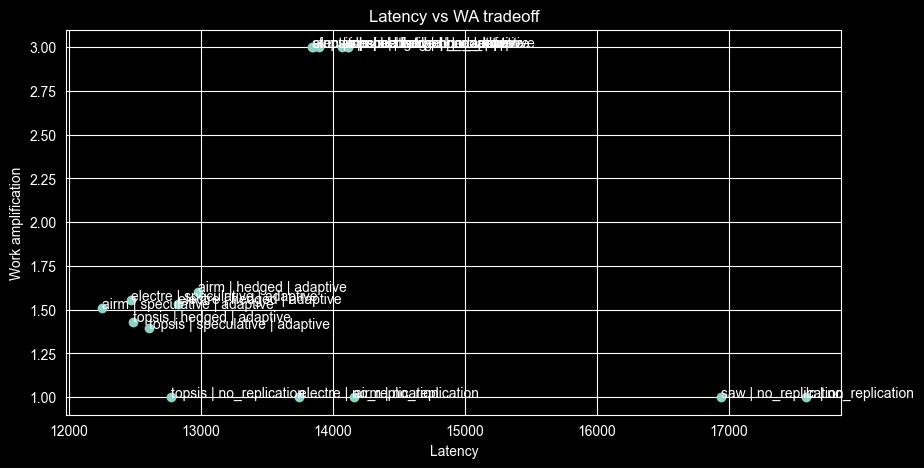

In [390]:
tradeoff = latency_stats.merge(
    wa_stats,
    left_index=True,
    right_index=True
)

plt.scatter(tradeoff["mean_x"], tradeoff["mean_y"])

for name, row in tradeoff.iterrows():
    plt.text(row["mean_x"], row["mean_y"], name)

plt.xlabel("Latency")
plt.ylabel("Work amplification")

plt.title("Latency vs WA tradeoff")

plt.show()

# CPU / MEM

In [391]:
socket_dist = (
    df
    .groupby(["method", "winner_socket"])
    .size()
    .reset_index(name="count")
)

socket_dist.head()

,method,winner_socket,count
0,airm | hedged | adaptive,,230
1,airm | hedged | adaptive,192.168.68.50_GQW_8001,7
2,airm | hedged | adaptive,192.168.68.50_GQW_8002,8
3,airm | hedged | adaptive,192.168.68.50_GQW_8003,23
4,airm | hedged | adaptive,192.168.68.50_GQW_8004,8


In [392]:
balance = (
    socket_dist
    .groupby("method")["count"]
    .agg(
        mean="mean",
        std="std"
    )
)

balance["cv"] = balance["std"] / balance["mean"]

balance.sort_values("cv")

,mean,std,cv
method,,,
electre | speculative | adaptive,35.714286,35.625477,0.997513
electre | hedged | adaptive,32.258065,33.942076,1.052204
topsis | hedged | adaptive,40.000000,44.579517,1.114488
topsis | speculative | adaptive,31.250000,44.528353,1.424907
airm | speculative | adaptive,30.303030,48.228936,1.591555
airm | hedged | adaptive,24.390244,41.566139,1.704212
airm | speculative | no_adaptive,23.255814,57.643441,2.478668
electre | speculative | no_adaptive,23.255814,61.398035,2.640116
topsis | speculative | no_adaptive,23.255814,63.480441,2.729659


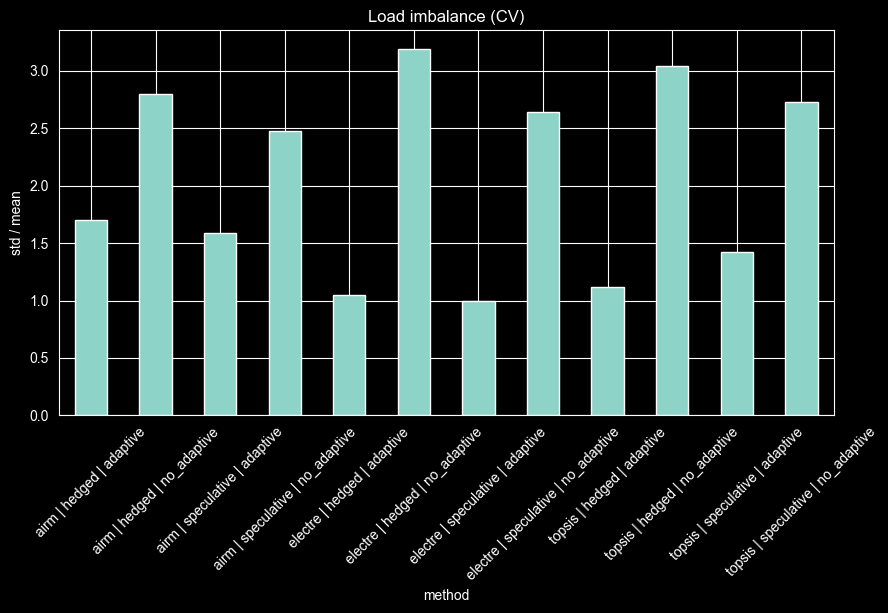

In [393]:
balance["cv"].plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

In [394]:
lat_by_group = (
    df
    .groupby("group")["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
)

lat_by_group

,mean,p95,p99
group,,,
balancer_only,15039.334645,27138.88937,38783.764334
replication_adaptive,12602.557152,15658.63472,18232.345628
replication_no_adaptive,13980.133906,18215.19053,18235.328082


In [396]:
baseline = lat_by_group.loc["balancer_only"]
rep_no = lat_by_group.loc["replication_no_adaptive"]
rep_ad = lat_by_group.loc["replication_adaptive"]

improvement = (baseline - rep_no) / baseline * 100

print("Replication improvement:")
print(improvement)

Replication improvement:
mean     7.042870
p95     32.881592
p99     52.982057
dtype: float64


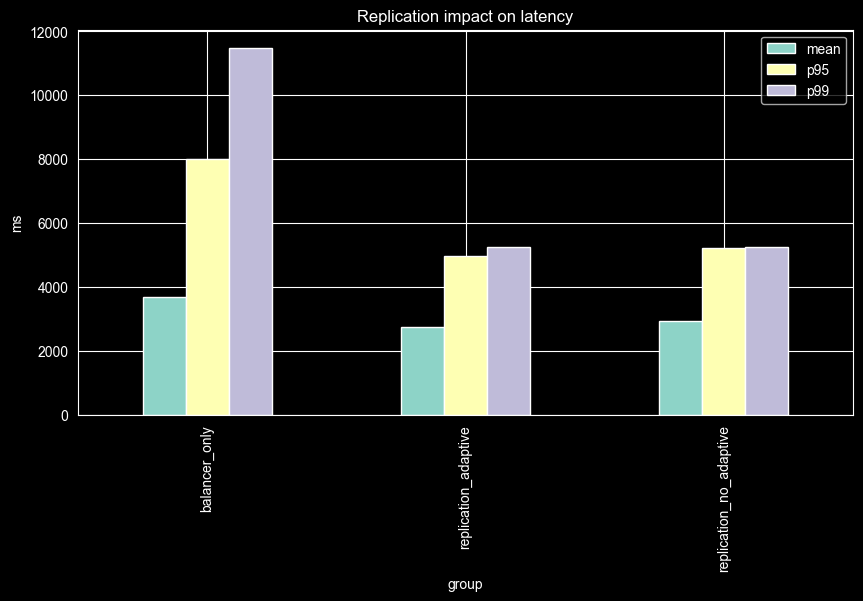

In [361]:
lat_by_group.plot(kind="bar")

plt.title("Replication impact on latency")

plt.ylabel("ms")

plt.show()

# Выгода адаптивности

In [308]:
wa_group = (
    df
    .groupby("group")["replicas"]
    .mean()
)

wa_group

group
balancer_only              1.000
replication_adaptive       1.555
replication_no_adaptive    3.000
Name: replicas, dtype: float64

In [309]:
adaptive_gain = (
                        (wa_group["replication_no_adaptive"]
                         - wa_group["replication_adaptive"])

                        / wa_group["replication_no_adaptive"]

                ) * 100

print("Adaptive WA reduction:", adaptive_gain)

Adaptive WA reduction: 48.16666666666667


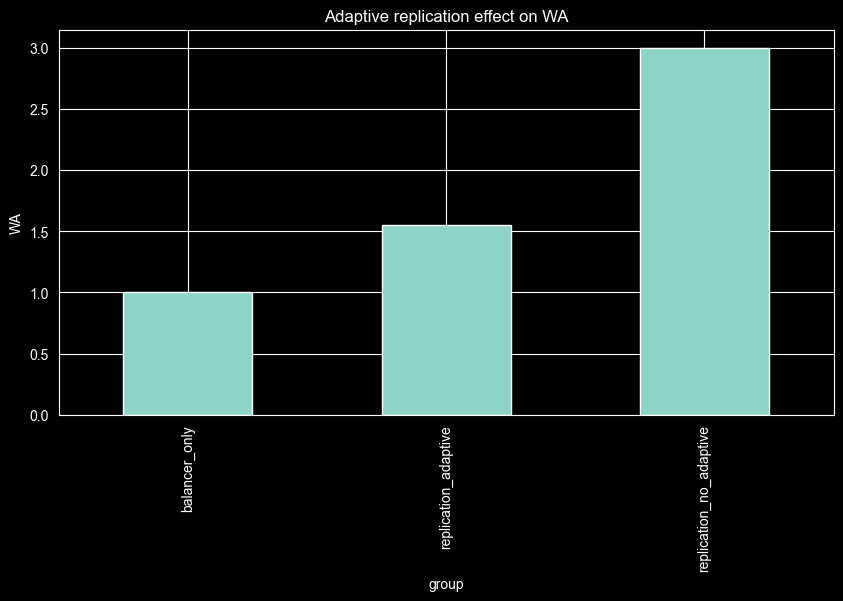

In [310]:
wa_group.plot(kind="bar")

plt.title("Adaptive replication effect on WA")

plt.ylabel("WA")

plt.show()

# CPU vs MEM Latency

In [311]:
df["is_cpu"] = df["endpoint"].str.startswith("cpu")

lat_cpu_mem = (

    df
    .groupby(["method","is_cpu"])["latency_ms"]
    .mean()
    .unstack()
)

lat_cpu_mem

is_cpu,False,True
method,,
airm | hedged | adaptive,2907.820359,2694.362407
airm | hedged | no_adaptive,2925.542283,2906.775102
airm | no_replication,3305.327540,2721.081064
airm | speculative | adaptive,2835.319818,2690.866554
airm | speculative | no_adaptive,3018.246022,2790.576198
electre | hedged | adaptive,2925.959250,2685.533064
electre | hedged | no_adaptive,3115.533673,2875.510967
electre | no_replication,3335.521533,2855.658973
electre | speculative | adaptive,2786.451435,2630.936964


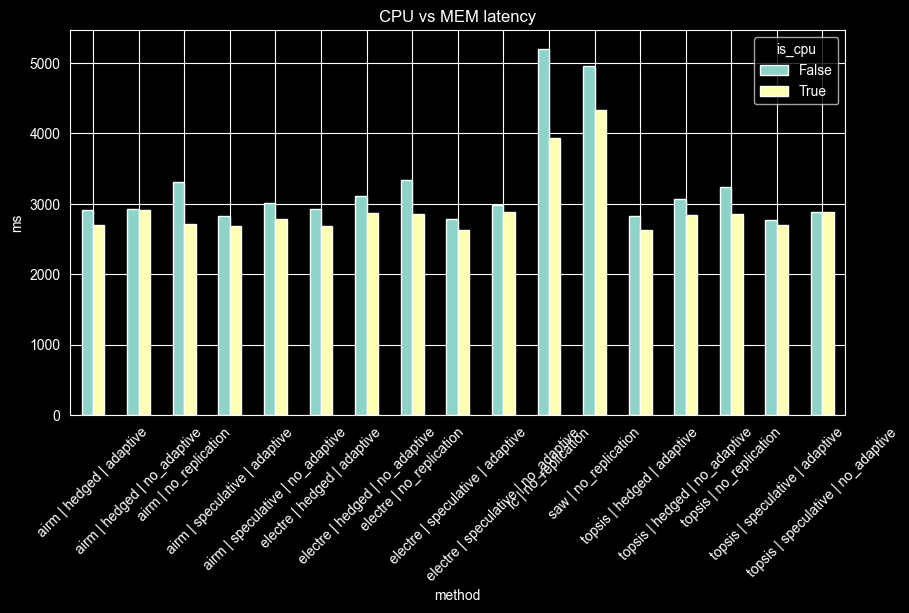

In [312]:
lat_cpu_mem.plot(kind="bar")

plt.title("CPU vs MEM latency")

plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

In [313]:
best_mean = latency_stats["mean"].idxmin()
best_p95 = latency_stats["p95"].idxmin()
best_wa = wa_stats["mean"].idxmin()

print("Best mean latency:", best_mean)
print("Best p95 latency:", best_p95)
print("Best WA:", best_wa)

Best mean latency: electre | speculative | adaptive
Best p95 latency: electre | speculative | adaptive
Best WA: airm | no_replication


# Сравнение с HAProxy

In [344]:
HAPROXY_DIR = Path("../assets/experiments/haproxy__1-4_secs")

def load_haproxy(folder):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        name = file.stem.replace("haproxy_", "")
        method = f"haproxy | {name}"

        rows = []

        for req in data["requests"]:

            upstream = req.get("upstream", {})
            signals = req.get("signals", {})

            winner = upstream.get("winner_socket")

            rows.append({
                "method": method,
                "group": "haproxy",

                "req_id": req["req_id"],
                "endpoint": req["endpoint"],

                "latency_ms": req["latency_ms"],
                "status": req["status"],
                "ok": req["ok"],

                "winner_socket": winner,
                "replicas": 1,

                "cpu_util": signals.get("cpu_util"),
                "mem_util": signals.get("mem_util"),
                "cpu_burn": signals.get("cpu_burn"),
                "mem_burn": signals.get("mem_burn"),
            })

        dfs.append(pd.DataFrame(rows))

    return dfs


haproxy_dfs = load_haproxy(HAPROXY_DIR)

df_haproxy = pd.concat(haproxy_dfs, ignore_index=True)

df_haproxy.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,haproxy | leastconn,haproxy,req-0,mem?seconds=1&mb=75,1085.8608,500,False,n1_p8006,1,None,None,None,None
1,haproxy | leastconn,haproxy,req-1,mem?seconds=2&mb=75,2808.6451,500,False,n2_p8005,1,None,None,None,None
2,haproxy | leastconn,haproxy,req-2,cpu?seconds=3,3035.9920,500,False,n2_p8006,1,None,None,None,None
3,haproxy | leastconn,haproxy,req-3,cpu?seconds=1,1024.6543,500,False,n3_p8003,1,None,None,None,None
4,haproxy | leastconn,haproxy,req-4,cpu?seconds=3,3025.1060,500,False,n3_p8004,1,None,None,None,None


In [345]:
df_all = pd.concat([df, df_haproxy], ignore_index=True)
df_all["backend"] = df_all["backend_port"].fillna(df_all["winner_socket"])
df_all.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,backend_port,replicas,cpu_util,mem_util,cpu_burn,mem_burn,is_cpu,backend
0,airm | no_replication,balancer_only,req-0,cpu?seconds=2,5498.5829,200,True,None,8001.0,1,28.9,19.8,True,None,True,8001.0
1,airm | no_replication,balancer_only,req-1,cpu?seconds=2,4634.4987,200,True,None,8001.0,1,0.0,19.4,True,None,True,8001.0
2,airm | no_replication,balancer_only,req-2,mem?seconds=2&mb=75,2151.8417,200,True,None,8005.0,1,26.1,17.2,None,True,False,8005.0
3,airm | no_replication,balancer_only,req-3,cpu?seconds=4,4091.4091,200,True,None,8005.0,1,25.2,19.1,True,None,True,8005.0
4,airm | no_replication,balancer_only,req-4,cpu?seconds=3,3130.9704,200,True,None,8001.0,1,26.8,18.5,True,None,True,8001.0


In [346]:
df_balancing = df_all[
    df_all["group"].isin(["balancer_only", "haproxy"])
].copy()

df_balancing["method"].unique()

<StringArray>
[   'airm | no_replication', 'electre | no_replication',
      'lc | no_replication',     'saw | no_replication',
  'topsis | no_replication',      'haproxy | leastconn',
         'haproxy | random',     'haproxy | roundrobin']
Length: 8, dtype: str

## Сравнение HAProxy алгоритмов

In [347]:
lat_compare = (
    df_balancing
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

lat_compare

,mean,p95,p99
method,,,
airm | no_replication,3020.799506,5802.408035,7075.433052
topsis | no_replication,3054.260751,6267.763535,7602.709308
electre | no_replication,3091.751353,5992.824380,7755.716722
lc | no_replication,4570.275612,9875.137820,12262.980188
saw | no_replication,4627.080143,9321.799420,11896.924744
haproxy | leastconn,5010.095337,14201.107065,18975.474786
haproxy | random,5166.953195,14421.623555,18989.093451
haproxy | roundrobin,6233.970579,18981.447390,19209.862460


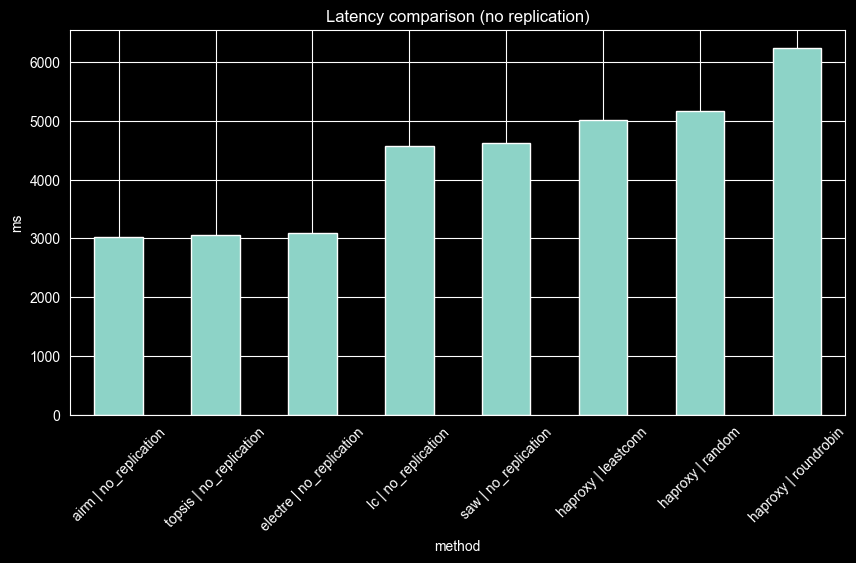

In [348]:
lat_compare["mean"].plot(kind="bar")

plt.title("Latency comparison (no replication)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

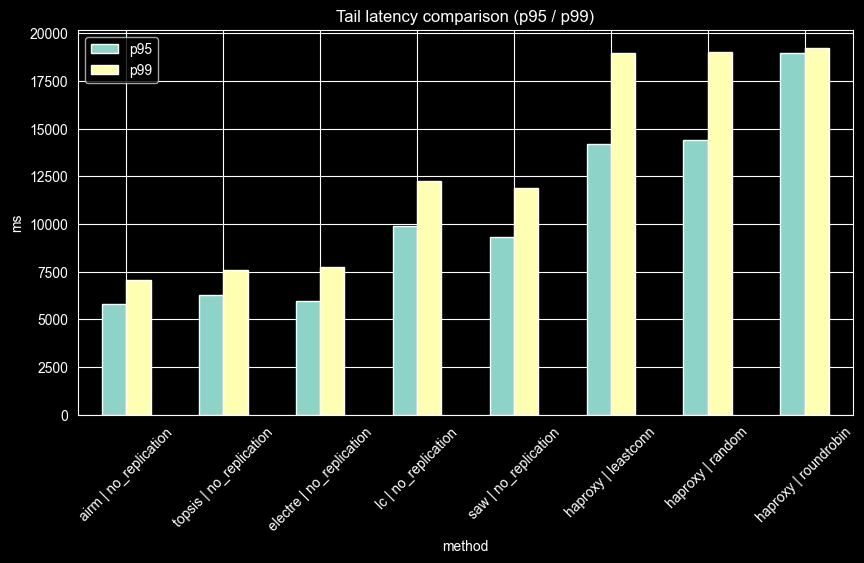

In [349]:
lat_compare[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency comparison (p95 / p99)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

## Балансировка нагрузки HAProxy

<Figure size 1200x600 with 0 Axes>

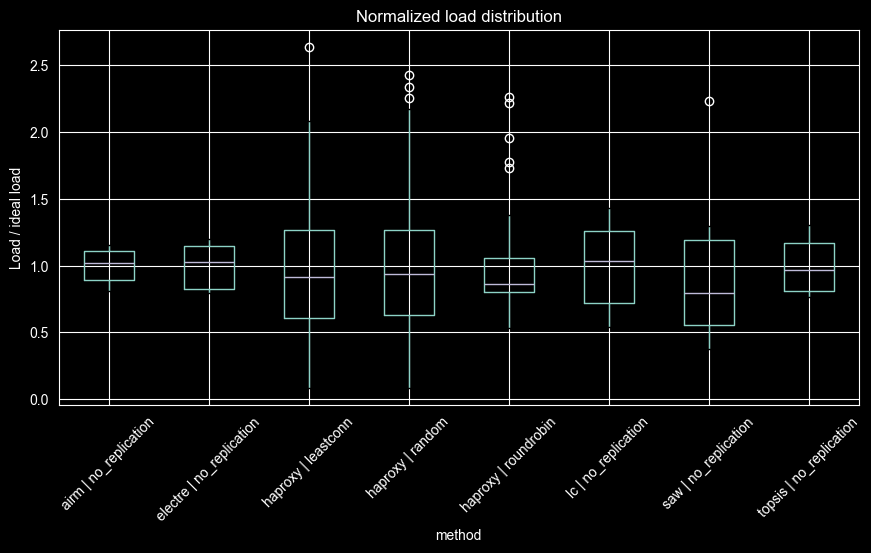

In [350]:
socket_counts["normalized"] = (
        socket_counts["count"] /
        socket_counts.groupby("method")["count"].transform("mean")
)

plt.figure(figsize=(12,6))

socket_counts.boxplot(
    column="normalized",
    by="method",
    rot=45
)

plt.title("Normalized load distribution")
plt.suptitle("")
plt.ylabel("Load / ideal load")

plt.show()

In [351]:
imbalance = socket_counts.groupby("method")["count"].agg(
    mean="mean",
    std="std"
)

imbalance["cv"] = imbalance["std"] / imbalance["mean"]

imbalance.sort_values("cv")

,mean,std,cv
method,,,
airm | no_replication,166.666667,23.796358,0.142778
electre | no_replication,166.666667,31.168360,0.187010
topsis | no_replication,166.666667,37.622688,0.225736
lc | no_replication,165.833333,59.327621,0.357755
haproxy | roundrobin,22.500000,9.402257,0.417878
haproxy | random,23.500000,13.420498,0.571085
haproxy | leastconn,23.500000,13.539914,0.576167
saw | no_replication,166.333333,114.109889,0.686031


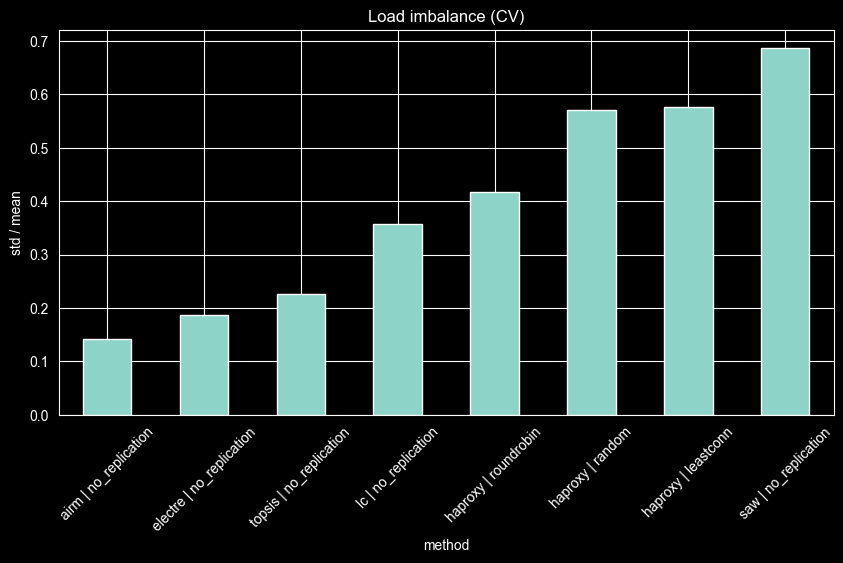

In [352]:
imbalance["cv"].sort_values().plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

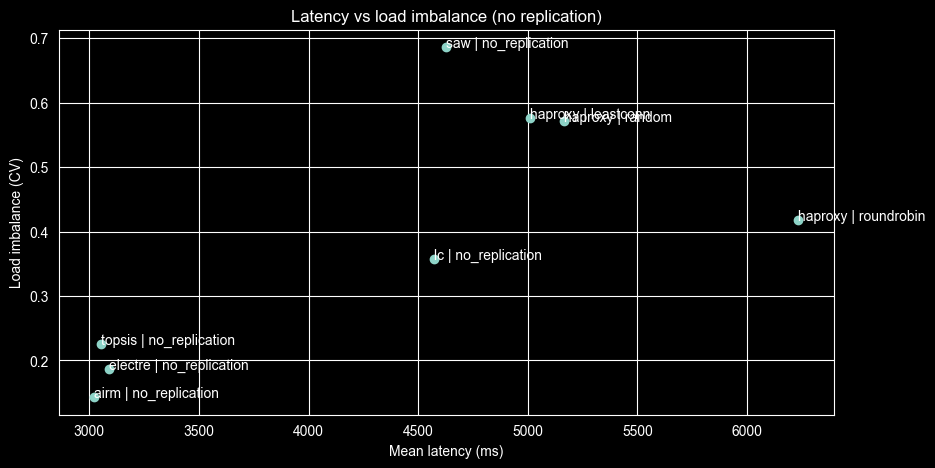

In [353]:
lat_mean = (
    df_balancing
    .groupby("method")["latency_ms"]
    .mean()
)

tradeoff = pd.concat([lat_mean, imbalance["cv"]], axis=1)

plt.scatter(tradeoff["latency_ms"], tradeoff["cv"])

for name, row in tradeoff.iterrows():
    plt.text(row["latency_ms"], row["cv"], name)

plt.xlabel("Mean latency (ms)")
plt.ylabel("Load imbalance (CV)")

plt.title("Latency vs load imbalance (no replication)")

plt.show()

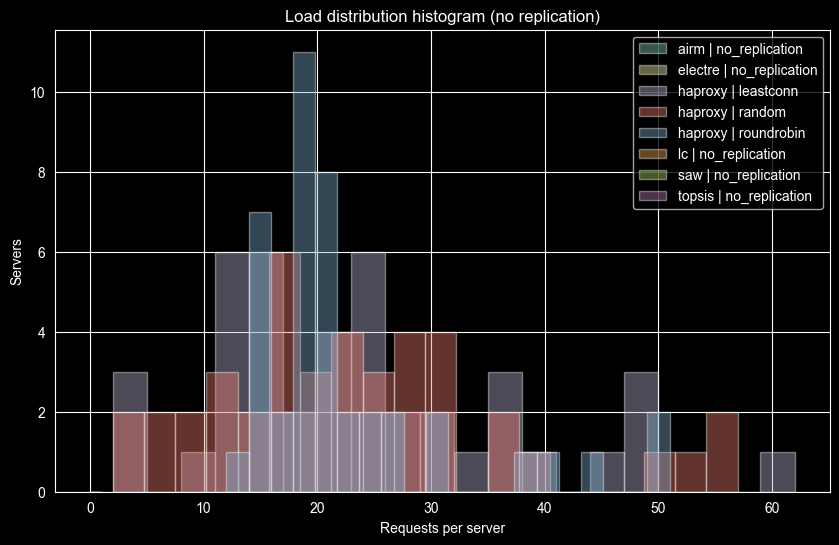

In [354]:
plt.figure(figsize=(10, 6))

methods = sorted(df_balancing["method"].unique())

for method in methods:
    sub = df_balancing[df_balancing["method"] == method]

    counts = (
        sub
        .groupby("winner_socket")
        .size()
    )

    plt.hist(
        counts,
        bins=20,
        alpha=0.4,
        label=method
    )

plt.title("Load distribution histogram (no replication)")
plt.xlabel("Requests per server")
plt.ylabel("Servers")

plt.legend()

plt.show()

## Числовые сравнения

In [355]:
lat_stats = (
    df_all
    .groupby("method")["latency_ms"]
    .agg(mean="mean", p95=p95, p99=p99)
)

my_algorithms = lat_stats[
    lat_stats.index.str.contains("no_replication")
]

haproxy_algorithms = lat_stats[
    lat_stats.index.str.contains("haproxy")
]

best_my = my_algorithms.sort_values("mean").iloc[0]
best_haproxy = haproxy_algorithms.sort_values("mean").iloc[0]

best_my_name = my_algorithms.sort_values("mean").index[0]
best_haproxy_name = haproxy_algorithms.sort_values("mean").index[0]

print("Best my algorithm:", best_my_name)
print("Best haproxy algorithm:", best_haproxy_name)

Best my algorithm: airm | no_replication
Best haproxy algorithm: haproxy | leastconn


In [356]:
mean_gain = (best_haproxy["mean"] - best_my["mean"]) / best_haproxy["mean"] * 100
p95_gain = (best_haproxy["p95"] - best_my["p95"]) / best_haproxy["p95"] * 100
p99_gain = (best_haproxy["p99"] - best_my["p99"]) / best_haproxy["p99"] * 100

print(f"Mean latency improvement: {mean_gain:.2f}%")
print(f"P95 latency improvement: {p95_gain:.2f}%")
print(f"P99 latency improvement: {p99_gain:.2f}%")

Mean latency improvement: 39.71%
P95 latency improvement: 59.14%
P99 latency improvement: 62.71%


In [357]:
imbalance = socket_counts.groupby("method")["count"].agg(mean="mean", std="std")
imbalance["cv"] = imbalance["std"] / imbalance["mean"]

best_my_cv = imbalance.loc[best_my_name, "cv"]
best_haproxy_cv = imbalance.loc[best_haproxy_name, "cv"]

cv_gain = (best_haproxy_cv - best_my_cv) / best_haproxy_cv * 100

print(f"Load balance improvement: {cv_gain:.2f}%")

Load balance improvement: 75.22%
